# TFM - Model Evaluation

## Objective

The main objective of this notebook is to evaluate and compare the predictive models developed in the previous phase. Their performance will be assessed using MAE, RMSE and R² metrics on the training and test datasets.

The models will also be compared against a baseline prediction to determine whether they provide a meaningful improvement. Finally, the best-performing model will be selected by considering its predictive accuracy, generalization capacity and potential overfitting.

Notebook: 07_Model Evaluation

Author: Ronald Baez

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Data, Predictions and Models

The modeling dataset, saved predictions and trained models from the previous phase are loaded. The same train-test split is reproduced to ensure that all models are evaluated under the same conditions.

In [2]:
# Load modeling dataset and saved predictions
df = pd.read_csv("../01_data/03_final_data/mlb_hitters_modeling.csv")
predictions = pd.read_csv("../01_data/03_final_data/model_predictions.csv")

# Define features and target
X = df.drop(columns=["log_salary", "salary"], errors="ignore")
y = df["log_salary"]

# Reproduce the same train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Load saved models
models = {
    "Baseline": joblib.load("../04_models/baseline.joblib"),
    "Linear Regression": joblib.load("../04_models/linear_regression.joblib"),
    "Ridge Regression": joblib.load("../04_models/ridge_regression.joblib"),
    "Decision Tree": joblib.load("../04_models/decision_tree.joblib"),
    "Random Forest": joblib.load("../04_models/random_forest.joblib")
}

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Models loaded: {list(models.keys())}")

Training set: (2947, 11)
Test set: (737, 11)
Models loaded: ['Baseline', 'Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest']


### Evaluation Metrics

The models are evaluated on the test dataset using three regression metrics:

- **MAE:** average absolute prediction error.
- **RMSE:** gives greater weight to large prediction errors.
- **R²:** measures the proportion of salary variability explained by the model.

In [3]:
# Evaluate models on the test set
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE":rmse,
        "R2": r2              
    })

evaluation_results = pd.DataFrame(results)
display(evaluation_results)

,Model,MAE,RMSE,R2
0,Baseline,1.256021,1.435018,-0.000003
1,Linear Regression,0.787446,0.981609,0.532089
2,Ridge Regression,0.787400,0.981595,0.532101
3,Decision Tree,0.830624,1.069026,0.445038
4,Random Forest,0.773474,1.002042,0.512406


### Model Comparison

The evaluation results are ordered by RMSE, where lower values indicate better predictive performance. MAE and R² are also considered to support the selection of the best model.


In [4]:
# Sort models by RMSE
evaluation_results = evaluation_results.sort_values(
    by="RMSE"
).reset_index(drop=True)

# Round metrics for easier interpretation
evaluation_results[["MAE", "RMSE", "R2"]] = evaluation_results[
    ["MAE", "RMSE", "R2"]
].round(4)

display(evaluation_results)

,Model,MAE,RMSE,R2
0,Ridge Regression,0.7874,0.9816,0.5321
1,Linear Regression,0.7874,0.9816,0.5321
2,Random Forest,0.7735,1.0020,0.5124
3,Decision Tree,0.8306,1.0690,0.4450
4,Baseline,1.2560,1.4350,-0.0000


### Train vs. Test Performance

The performance of each model is compared between the training and test datasets. A large difference between both results may indicate overfitting, while similar values suggest better generalization to unseen data.


In [5]:
# Compare training and test performance
generalization_results = []

for name, model in models.items():
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    generalization_results.append({
        "Model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "RMSE Gap": (
            np.sqrt(mean_squared_error(y_test, test_pred))
            - np.sqrt(mean_squared_error(y_train, train_pred))
        )
    })

generalization_results = pd.DataFrame(generalization_results).round(4)

display(generalization_results)

,Model,Train RMSE,Test RMSE,RMSE Gap
0,Baseline,1.4492,1.4350,-0.0142
1,Linear Regression,1.0034,0.9816,-0.0218
2,Ridge Regression,1.0034,0.9816,-0.0218
3,Decision Tree,0.9672,1.0690,0.1018
4,Random Forest,0.6136,1.0020,0.3885


### Best Model Diagnostics

The model with the lowest test RMSE is selected for further analysis. Actual and predicted values are compared, and the distribution of residuals is examined to identify possible systematic prediction errors.


In [6]:
# Select the best model
best_model_name = evaluation_results.iloc[0]["Model"]
best_model = models[best_model_name]

# Generate predictions
best_predictions = best_model.predict(X_test)
residuals = y_test - best_predictions

print(f"Best model: {best_model_name}")

Best model: Ridge Regression


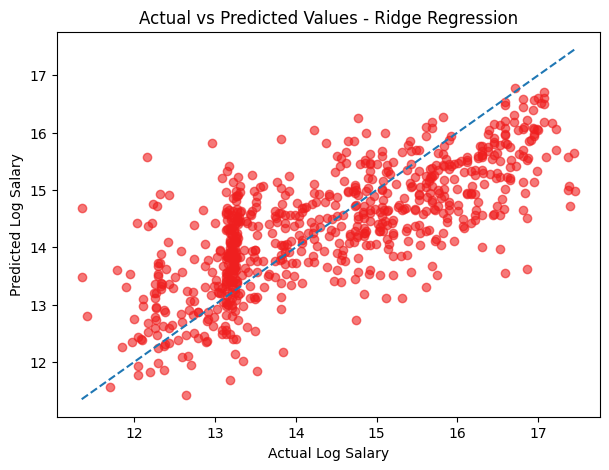

In [14]:
# Actual vs predicted values
plt.figure(figsize=(7, 5))

plt.scatter(y_test, best_predictions, color="#ef1f1f", alpha=0.6)

min_value = min(y_test.min(), best_predictions.min())
max_value = max(y_test.max(), best_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Log Salary")
plt.ylabel("Predicted Log Salary")
plt.title(f"Actual vs Predicted Values - {best_model_name}")
plt.show()

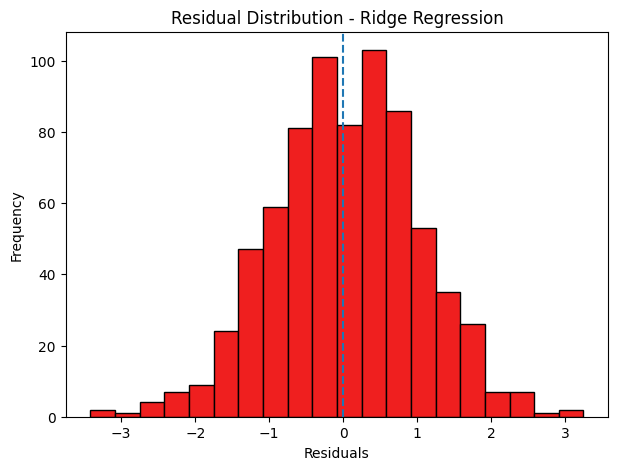

In [15]:
# Residual distribution
plt.figure(figsize=(7, 5))

plt.hist(residuals, bins=20, color="#ef1f1f", edgecolor="black")

plt.axvline(0, linestyle="--")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution - {best_model_name}")
plt.show()

### Results Export

The final evaluation table is saved to preserve the comparison results and facilitate their use in the interpretation phase and final report.


In [9]:
# Save evaluation results
evaluation_results.to_csv(
    "../01_data/03_final_data/model_evaluation_results.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


### Evaluation Conclusions

The main evaluation results are summarized to identify the best-performing model, its improvement over the baseline and its ability to generalize to unseen data.


In [10]:
# Summarize the main evaluation results
best_result = evaluation_results.iloc[0]

best_model_name = best_result["Model"]
best_rmse = best_result["RMSE"]
best_mae = best_result["MAE"]
best_r2 = best_result["R2"]

baseline_rmse = evaluation_results.loc[
    evaluation_results["Model"] == "Baseline",
    "RMSE"
].iloc[0]

rmse_improvement = baseline_rmse - best_rmse

best_gap = generalization_results.loc[
    generalization_results["Model"] == best_model_name,
    "RMSE Gap"
].iloc[0]

print(f"Best model: {best_model_name}")
print(f"Test MAE: {best_mae}")
print(f"Test RMSE: {best_rmse}")
print(f"Test R²: {best_r2}")
print(f"RMSE improvement over baseline: {rmse_improvement:.4f}")
print(f"Train-test RMSE gap: {best_gap:.4f}")

Best model: Ridge Regression
Test MAE: 0.7874
Test RMSE: 0.9816
Test R²: 0.5321
RMSE improvement over baseline: 0.4534
Train-test RMSE gap: -0.0218


### Final Evaluation

Ridge Regression achieved the best overall performance, with a test RMSE of 0.9816, a MAE of 0.7874 and an R² of 0.5321. The model reduced the RMSE by 0.4534 compared with the baseline, demonstrating a meaningful improvement in salary prediction.

The small train-test RMSE gap indicates stable performance and no relevant evidence of overfitting. Therefore, Ridge Regression was selected as the final model due to its balance between predictive accuracy, simplicity and generalization capacity.